# 02 - Modélisation & Évaluation
**Tâche** : Régression — Prédiction du ROI Marketing

> `ROI = Sales / (TV + Radio + Social Media)`
>
> **Question business** : *Quel est le retour sur investissement généré par une combinaison de budgets marketing ?*

## 1. Imports

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Modèles ML
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

import shap
import joblib
import os

print('✅ Imports OK')

✅ Imports OK


## 2. Chargement des données

In [2]:
df = pd.read_csv('../data/processed/marketing_and_sales_clean.csv')

print(f'Shape : {df.shape}')
print(f'\nValeurs manquantes :\n{df.isnull().sum()}')
display(df.head())

Shape : (4546, 5)

Valeurs manquantes :
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


,TV,Radio,Social Media,Influencer,Sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


## 3. Création de la variable cible ROI

In [3]:
# ── Calcul du ROI ────────────────────────────────────────────
# ROI = Sales / (TV + Radio + Social Media)
# Interprétation : pour 1 unité de budget investi, combien de ventes génère-t-on ?

df['Total_Budget'] = df['TV'] + df['Radio'] + df['Social Media']
df['ROI'] = df['Sales'] / df['Total_Budget']

print('✅ Colonne ROI créée')
print(f'\nStatistiques du ROI :')
display(df['ROI'].describe().round(4))

✅ Colonne ROI créée

Statistiques du ROI :


count    4546.0000
mean        2.5475
std         0.2817
min         1.2654
25%         2.4089
50%         2.5520
75%         2.6996
max         3.7493
Name: ROI, dtype: float64

In [ ]:
df.head()

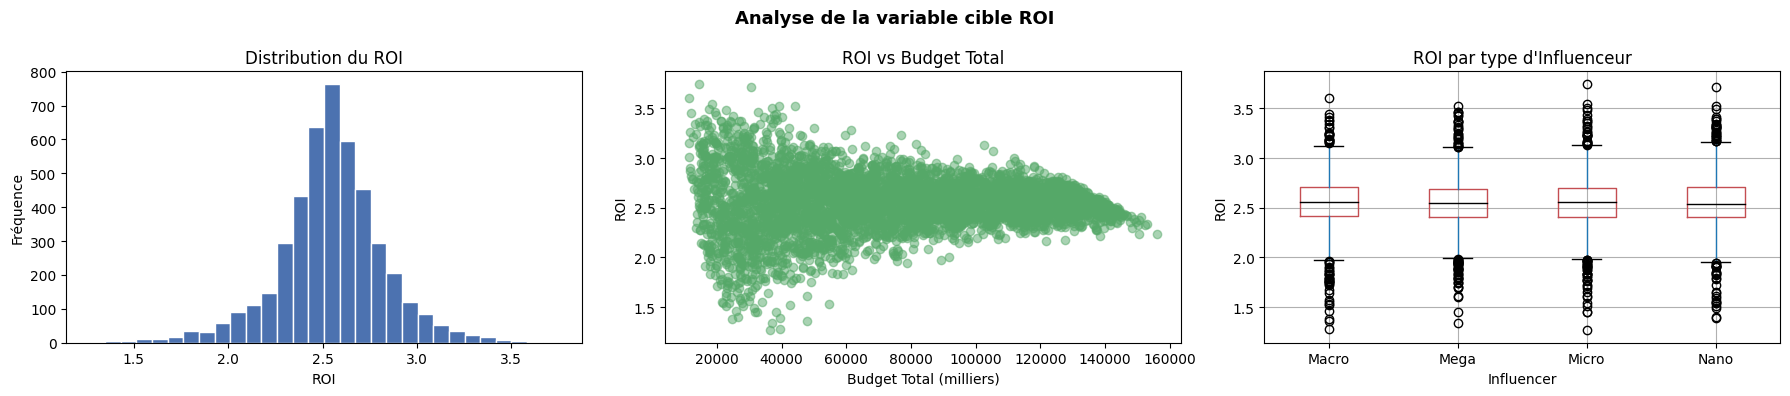

ROI moyen  : 2.5475
ROI médian : 2.5520
ROI min    : 1.2654
ROI max    : 3.7493


In [4]:
# ── Visualisation du ROI ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Distribution
axes[0].hist(df['ROI'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution du ROI')
axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Fréquence')

# ROI vs Budget Total
axes[1].scatter(df['Total_Budget'], df['ROI'], alpha=0.5, color='#55A868')
axes[1].set_title('ROI vs Budget Total')
axes[1].set_xlabel('Budget Total (milliers)')
axes[1].set_ylabel('ROI')

# ROI par type d'influenceur
df.boxplot(column='ROI', by='Influencer', ax=axes[2],
           boxprops=dict(color='#C44E52'),
           medianprops=dict(color='black'))
axes[2].set_title('ROI par type d\'Influenceur')
axes[2].set_xlabel('Influencer')
axes[2].set_ylabel('ROI')
plt.suptitle('')

plt.suptitle('Analyse de la variable cible ROI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'ROI moyen  : {df["ROI"].mean():.4f}')
print(f'ROI médian : {df["ROI"].median():.4f}')
print(f'ROI min    : {df["ROI"].min():.4f}')
print(f'ROI max    : {df["ROI"].max():.4f}')

## 4. Préparation des données

In [5]:
# ── 4.1 Encodage ordinal de Influencer ──────────────────────
INFLUENCER_ORDER = ['Nano', 'Micro', 'Macro', 'Mega']

df['Influencer_encoded'] = OrdinalEncoder(
    categories=[INFLUENCER_ORDER]
).fit_transform(df[['Influencer']]).astype(int)

print('Mapping Influencer :')
print({v: i for i, v in enumerate(INFLUENCER_ORDER)})

Mapping Influencer :
{'Nano': 0, 'Micro': 1, 'Macro': 2, 'Mega': 3}


In [6]:
# ── 4.2 Features / Cible ────────────────────────────────────
FEATURES = ['TV', 'Radio', 'Social Media', 'Influencer_encoded']
TARGET   = 'ROI'

X = df[FEATURES]
y = df[TARGET]

print(f'Features : {FEATURES}')
print(f'Cible    : {TARGET}')
print(f'Shape X  : {X.shape} | Shape y : {y.shape}')

Features : ['TV', 'Radio', 'Social Media', 'Influencer_encoded']
Cible    : ROI
Shape X  : (4546, 4) | Shape y : (4546,)


In [7]:
# ── 4.3 Train / Test split 80/20 ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')

Train : 3636 lignes | Test : 910 lignes


In [8]:
# ── 4.4 Pipeline preprocessing (anti data leakage) ──────────
numeric_features     = ['TV', 'Radio', 'Social Media']
passthrough_features = ['Influencer_encoded']

preprocessor = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), numeric_features),
    ('pass',   'passthrough',   passthrough_features),
])

# Fit UNIQUEMENT sur le train
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

feature_names = numeric_features + passthrough_features

print('✅ Preprocessing OK — data leakage évité')
print(f'Shape train : {X_train_proc.shape}')

✅ Preprocessing OK — data leakage évité
Shape train : (3636, 4)


## 5. Modélisation — 4 modèles comparés

In [9]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Entraîne un modèle et retourne ses métriques."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')

    print(f'\n── {name} ──')
    print(f'  MAE  : {mae:.6f}')
    print(f'  RMSE : {rmse:.6f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  CV R² (mean ± std) : {cv.mean():.4f} ± {cv.std():.4f}')

    return {
        'Modèle'    : name,
        'MAE'       : round(mae, 6),
        'RMSE'      : round(rmse, 6),
        'R²'        : round(r2, 4),
        'CV R² mean': round(cv.mean(), 4),
        'CV R² std' : round(cv.std(), 4),
        'model_obj' : model,
        'y_pred'    : y_pred,
    }

results = []

In [10]:
# ── Modèle 1 : Régression Linéaire (baseline) ───────────────
lr = LinearRegression()
results.append(evaluate_model('Régression Linéaire', lr,
                               X_train_proc, y_train,
                               X_test_proc,  y_test))


── Régression Linéaire ──
  MAE  : 0.102991
  RMSE : 0.151428
  R²   : 0.7074
  CV R² (mean ± std) : 0.7093 ± 0.0131


In [11]:
# ── Modèle 2 : Random Forest ─────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
results.append(evaluate_model('Random Forest', rf,
                               X_train_proc, y_train,
                               X_test_proc,  y_test))


── Random Forest ──
  MAE  : 0.049626
  RMSE : 0.072635
  R²   : 0.9327
  CV R² (mean ± std) : 0.9185 ± 0.0078


In [12]:
# ── Modèle 3 : Gradient Boosting ─────────────────────────────
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
results.append(evaluate_model('Gradient Boosting', gb,
                               X_train_proc, y_train,
                               X_test_proc,  y_test))


── Gradient Boosting ──
  MAE  : 0.050853
  RMSE : 0.073724
  R²   : 0.9306
  CV R² (mean ± std) : 0.9217 ± 0.0084


In [13]:
# ── Modèle 4 : MLP (Deep Learning) ───────────────────────────
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
results.append(evaluate_model('MLP (Deep Learning)', mlp,
                               X_train_proc, y_train,
                               X_test_proc,  y_test))


── MLP (Deep Learning) ──
  MAE  : 0.046444
  RMSE : 0.069437
  R²   : 0.9385
  CV R² (mean ± std) : 0.9329 ± 0.0050


## 6. Tableau comparatif

In [14]:
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['model_obj', 'y_pred']}
    for r in results
])
df_results = df_results.sort_values('R²', ascending=False).reset_index(drop=True)

display(df_results.style
        .highlight_max(subset=['R²', 'CV R² mean'], color='lightgreen')
        .highlight_min(subset=['MAE', 'RMSE', 'CV R² std'], color='lightgreen'))

,Modèle,MAE,RMSE,R²,CV R² mean,CV R² std
0,MLP (Deep Learning),0.046444,0.069437,0.938500,0.932900,0.005000
1,Random Forest,0.049626,0.072635,0.932700,0.918500,0.007800
2,Gradient Boosting,0.050853,0.073724,0.930600,0.921700,0.008400
3,Régression Linéaire,0.102991,0.151428,0.707400,0.709300,0.013100


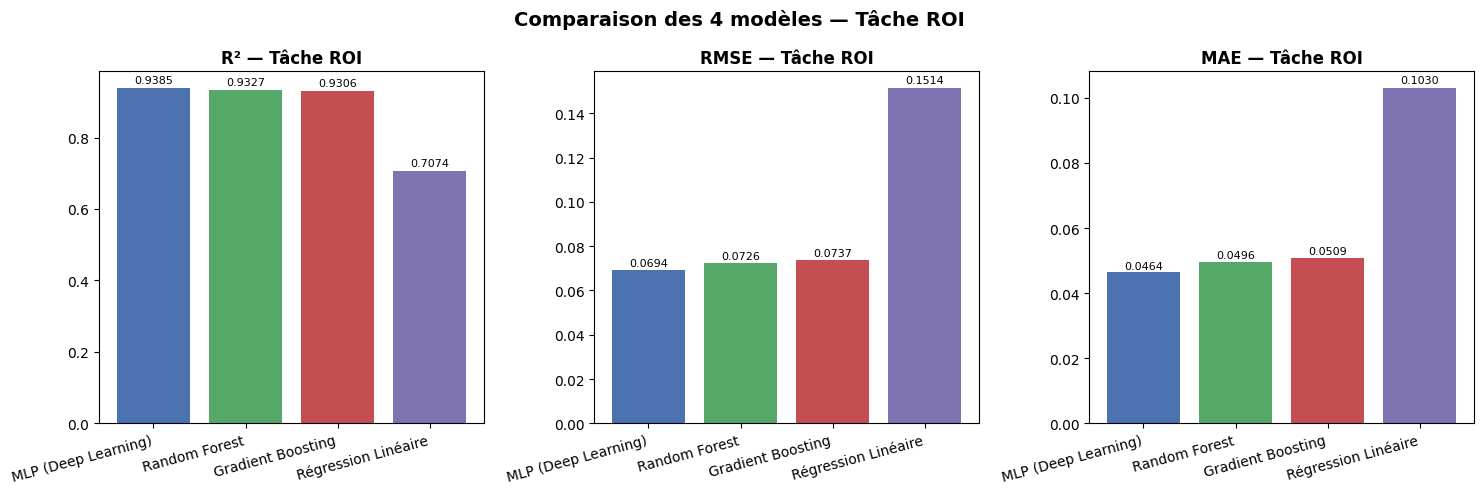

In [15]:
# ── Graphique comparatif ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    bars = ax.bar(df_results['Modèle'], df_results[metric], color=colors)
    ax.set_title(f'{metric} — Tâche ROI', fontsize=12, fontweight='bold')
    ax.set_xticklabels(df_results['Modèle'], rotation=15, ha='right')
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparaison des 4 modèles — Tâche ROI',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Analyse des résidus

✅ Meilleur modèle : MLP (Deep Learning) (R² = 0.9385)


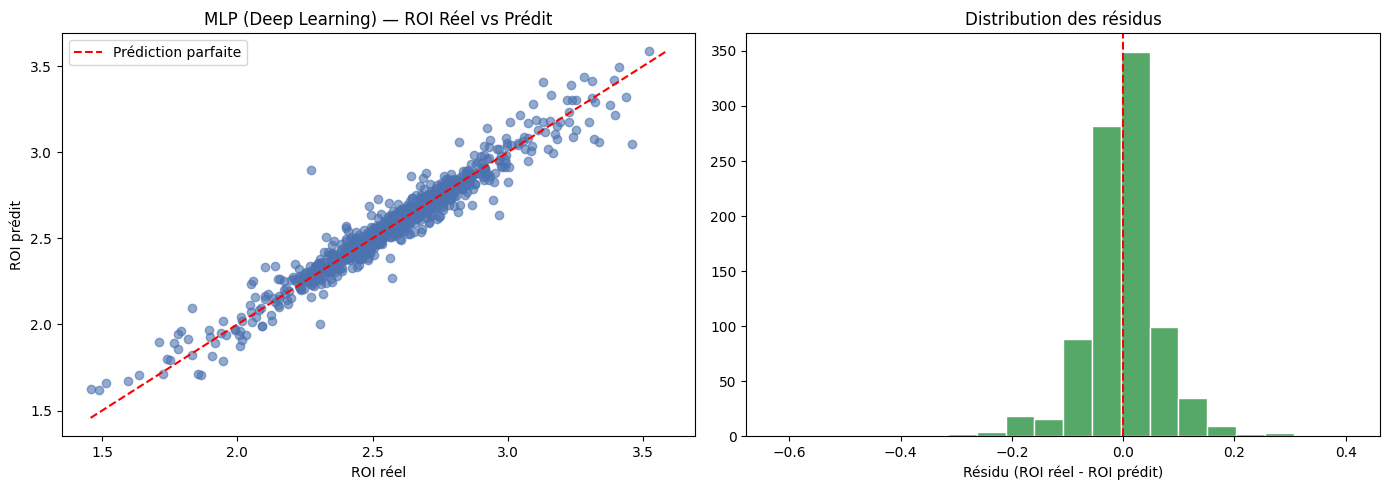

In [16]:
best        = max(results, key=lambda r: r['R²'])
best_name   = best['Modèle']
best_model  = best['model_obj']
y_pred_best = best['y_pred']
residuals   = y_test.values - y_pred_best

print(f'✅ Meilleur modèle : {best_name} (R² = {best["R²"]})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Réel vs Prédit
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='#4C72B0')
lims = [min(y_test.min(), y_pred_best.min()),
        max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', label='Prédiction parfaite')
axes[0].set_xlabel('ROI réel')
axes[0].set_ylabel('ROI prédit')
axes[0].set_title(f'{best_name} — ROI Réel vs Prédit')
axes[0].legend()

# Distribution résidus
axes[1].hist(residuals, bins=20, color='#55A868', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Résidu (ROI réel - ROI prédit)')
axes[1].set_title('Distribution des résidus')

plt.tight_layout()
plt.show()

## 8. Interprétabilité — Feature Importance

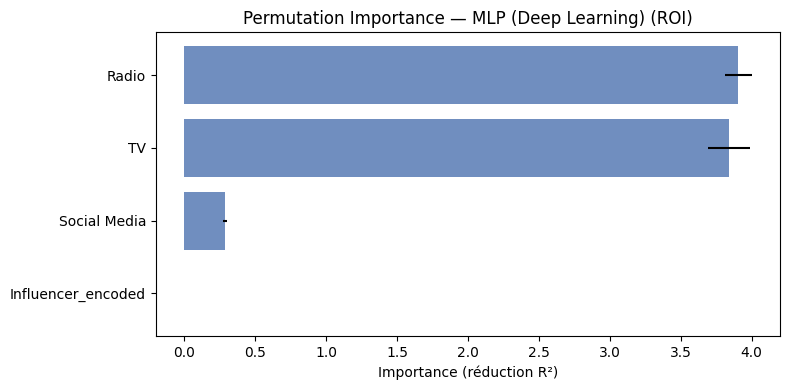

,Feature,Importance (mean),Std
1,Radio,3.906723,0.093504
0,TV,3.841112,0.146029
2,Social Media,0.286724,0.012708
3,Influencer_encoded,-0.000076,0.000796


In [17]:
# ── Permutation Importance ───────────────────────────────────
perm_imp = permutation_importance(
    best_model, X_test_proc, y_test,
    n_repeats=10, random_state=42
)

df_perm = pd.DataFrame({
    'Feature'          : feature_names,
    'Importance (mean)': perm_imp.importances_mean,
    'Std'              : perm_imp.importances_std,
}).sort_values('Importance (mean)', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(df_perm['Feature'], df_perm['Importance (mean)'],
         xerr=df_perm['Std'], color='#4C72B0', alpha=0.8)
plt.xlabel('Importance (réduction R²)')
plt.title(f'Permutation Importance — {best_name} (ROI)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(df_perm)

In [18]:
# ── Feature importance native (tree-based uniquement) ────────
if hasattr(best_model, 'feature_importances_'):
    df_fi = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(8, 4))
    plt.barh(df_fi['Feature'], df_fi['Importance'],
             color='#C44E52', alpha=0.8)
    plt.xlabel('Importance (réduction variance)')
    plt.title(f'Feature Importance native — {best_name} (ROI)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f'Pas de feature_importances_ natif pour {best_name}')

Pas de feature_importances_ natif pour MLP (Deep Learning)


## 9. SHAP — Explicabilité avancée

  0%|          | 0/50 [00:00<?, ?it/s]

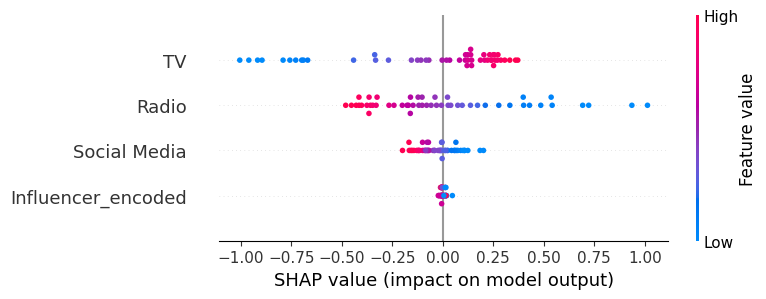

In [22]:
X_test_df = pd.DataFrame(X_test_proc, columns=feature_names)

if best_name in ['Random Forest', 'Gradient Boosting']:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_df)
    shap_display = X_test_df  # même nombre de lignes

else:
    # Pour MLP : on limite à 50 lignes PARTOUT
    X_sample     = X_test_df.iloc[:50]
    explainer    = shap.KernelExplainer(best_model.predict, shap.sample(X_test_df, 50))
    shap_values  = explainer.shap_values(X_sample)
    shap_display = X_sample  # même nombre de lignes que shap_values

# Summary plot — même objet pour les deux arguments
shap.summary_plot(shap_values, shap_display,
                  feature_names=feature_names, show=True)

In [23]:
# Explication locale — 1ère observation
# Force plot — explication locale 1ère observation
if best_name in ['Random Forest', 'Gradient Boosting']:
    first_shap  = shap_values[0]
    first_input = X_test_df.iloc[0]
else:
    # MLP : shap_values calculés sur X_sample (50 lignes)
    first_shap  = shap_values[0]
    first_input = X_sample.iloc[0]

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    first_shap,
    first_input,
    feature_names=feature_names
)

## 10. Sauvegarde du meilleur modèle

In [20]:
os.makedirs('../model', exist_ok=True)

joblib.dump(best_model,   '../model/best_model_roi.pkl')
joblib.dump(preprocessor, '../model/preprocessor_roi.pkl')

print(f'✅ Modèle ROI sauvegardé : {best_name}')
print('  → ../model/best_model_roi.pkl')
print('  → ../model/preprocessor_roi.pkl')

✅ Modèle ROI sauvegardé : MLP (Deep Learning)
  → ../model/best_model_roi.pkl
  → ../model/preprocessor_roi.pkl


## 11. Conclusion & Recommandation

In [21]:
print('=' * 55)
print('SYNTHÈSE — TÂCHE ROI')
print('=' * 55)
display(df_results[['Modèle', 'R²', 'RMSE', 'MAE', 'CV R² mean', 'CV R² std']])

print(f'\n✅ Modèle retenu : {best_name}')
print(f'   R²          = {best["R²"]}')
print(f'   RMSE        = {best["RMSE"]}')
print(f'   MAE         = {best["MAE"]}')
print(f'   CV R² mean  = {best["CV R² mean"]}')

print('\nJustification :')
print('  - Meilleur R² sur le test set')
print('  - CV stable (faible écart-type)')
print('  - Interprétable via SHAP et feature importance')
print('  - Meilleur compromis performance / complexité')
print('\nIntérêt business :')
print('  - Permet d\'identifier les canaux les plus rentables')
print('  - Optimise la répartition budgétaire')
print('  - Détecte les rendements décroissants')
print('  - Aide le CMO à maximiser le ROI global')

SYNTHÈSE — TÂCHE ROI


,Modèle,R²,RMSE,MAE,CV R² mean,CV R² std
0,MLP (Deep Learning),0.9385,0.069437,0.046444,0.9329,0.0050
1,Random Forest,0.9327,0.072635,0.049626,0.9185,0.0078
2,Gradient Boosting,0.9306,0.073724,0.050853,0.9217,0.0084
3,Régression Linéaire,0.7074,0.151428,0.102991,0.7093,0.0131



✅ Modèle retenu : MLP (Deep Learning)
   R²          = 0.9385
   RMSE        = 0.069437
   MAE         = 0.046444
   CV R² mean  = 0.9329

Justification :
  - Meilleur R² sur le test set
  - CV stable (faible écart-type)
  - Interprétable via SHAP et feature importance
  - Meilleur compromis performance / complexité

Intérêt business :
  - Permet d'identifier les canaux les plus rentables
  - Optimise la répartition budgétaire
  - Détecte les rendements décroissants
  - Aide le CMO à maximiser le ROI global
